################################################## Before
 overfit, not fit.
I'm not sure what you're trying to say.  
######################################################################################################################################################
INFO:nncf:731 ignored nodes were found by patterns in the NNCFGraph
INFO:nncf:731 ignored nodes were found by patterns in the NNCFGraph
INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│ Weight compression mode   │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│ int4_asym                 │ 100% (1 / 1)                │ 100% (1 / 1)                           │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

Quantize model.decoder.layers.5.self_attn.v_proj.weight to int4_asym

Tune:  _nncf.external_quantizers.FQ_LORA_model_decoder_layers_5_self_attn_v_proj_weight.input_low
Tune:  _nncf.external_quantizers.FQ_LORA_model_decoder_layers_5_self_attn_v_proj_weight._input_range_param_storage
Tune:  _nncf.external_quantizers.FQ_LORA_model_decoder_layers_5_self_attn_v_proj_weight._lora_A
Tune:  _nncf.external_quantizers.FQ_LORA_model_decoder_layers_5_self_attn_v_proj_weight._lora_B
INFO:nncf:Wrapping a dummy tensor for input attention_mask
defaultdict(<class 'list'>, {'_lora_A': [0.45703125], '_lora_B': [0.45703125], 'input_low': [4.357243061065674], 'input_range': [8.615947723388672], 'losses': [8.25]})
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrapping a dummy tensor for input attention_mask
INFO:nncf:Wrap

/tmp/ipykernel_288985/1349256990.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


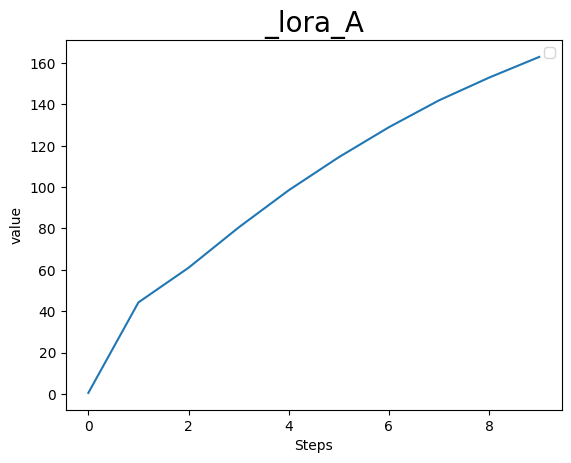

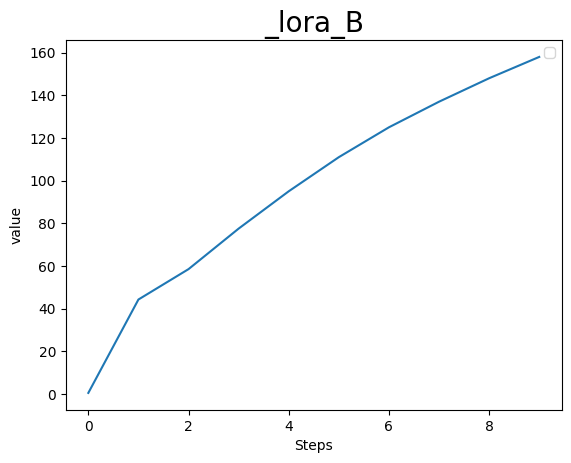

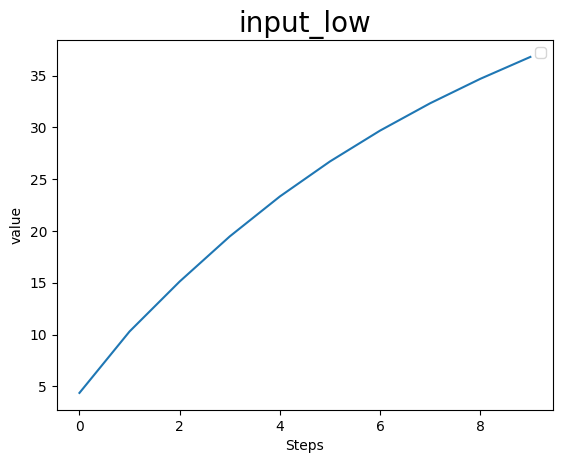

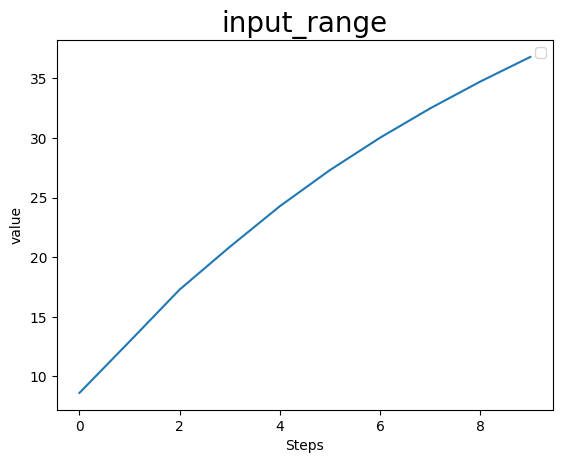

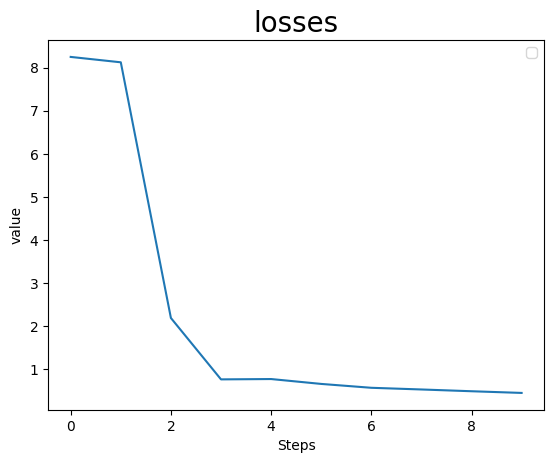

################################################## After
 overfitfit over over overfitfitfitfitfitfitfit over over over over overfit 
######################################################################################################################################################
Peak memory usage: 0.61 Gb


In [ ]:
# Copyright (c) 2025 Intel Corporation
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#      http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer

import nncf


def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(0)
GROUP_SIZE = 64
MODE = nncf.CompressWeightsMode.INT4_ASYM
BACKUP_MODE = nncf.BackupMode.INT8_ASYM
SCALE_ESTIMATION = False

model_id = "facebook/opt-125m"
# model_id = "HuggingFaceTB/SmolLM-1.7B-Instruct"
# model_id = "hf-internal-testing/tiny-random-OPTForCausalLM"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    low_cpu_mem_usage=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
overfit_prompt = "overfit"
# message = [{"role": "user", "content": overfit_prompt}]
# inputs = tokenizer.apply_chat_template(message, add_generation_prompt=True, return_tensors="pt").cuda()
inputs = tokenizer(overfit_prompt, return_tensors="pt").to("cuda")
labels = inputs["input_ids"].cuda()
attention_mask = inputs["attention_mask"].cuda()
input_ids = labels[:, :-1]
labels = labels[:, 1:]
position_ids = torch.cumsum(attention_mask, axis=1).cuda() - 1
position_ids[attention_mask == 0] = 1
dataset = [
    {"input_ids": input_ids, "attention_mask": attention_mask[:, :-1]}
]  # , "position_ids": position_ids[:, :-1]}]
# dataset = [inputs]

output = model.generate(**inputs, do_sample=False)  # , min_new_tokens=128, max_new_tokens=128)
print("#" * 50 + " Before\n", tokenizer.decode(output[0], skip_special_tokens=True), "\n" + "#" * 150)

model = nncf.compress_weights(
    model,
    ratio=1,
    group_size=GROUP_SIZE,
    mode=MODE,
    all_layers=True,
    backup_mode=BACKUP_MODE,
    scale_estimation=SCALE_ESTIMATION,
    dataset=nncf.Dataset(dataset),
    compression_format=nncf.CompressionFormat.FQ_LORA,
    ignored_scope=nncf.IgnoredScope(
        patterns=[r"^(?!.*OPTDecoderLayer\[5\]/OPTAttention\[self_attn\]/Linear\[v_proj\]/l.*$).*$"]
    ),
)

# TODO: should do inside, for training pipeline.
for param in model.parameters():
    param.requires_grad = False
for quantizer in model._nncf.external_quantizers.values():
    if quantizer.num_bits == 4:
        quantizer.enable_gradients()
for name, param in model.named_parameters():
    if param.requires_grad:
        print("Tune: ", name)


# We'll teach the model to repeatedly say "overfit".
labels = tokenizer("overfit " * 10, return_tensors="pt")["input_ids"].to("cuda:0")
input_ids = labels[:, :-1]
labels = labels[:, 1:]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

dumps = defaultdict(list)

for i in range(10):
    optimizer.zero_grad()
    loss = model(input_ids=input_ids, labels=labels).loss
    dumps["_lora_A"].append(torch.linalg.norm(quantizer._lora_A.data).item())
    dumps["_lora_B"].append(torch.linalg.norm(quantizer._lora_B.data).item())
    dumps["input_low"].append(torch.linalg.norm(quantizer.input_low.data).item())
    dumps["input_range"].append(torch.linalg.norm(quantizer.input_range.data).item())
    dumps["losses"].append(float(loss))
    if i == 0:
        print(dumps)
    loss.backward()
    optimizer.step()

# Check that loss is decreasing
for name, values in dumps.items():
    plt.plot(values)
    plt.title(name, fontsize=20)
    plt.xlabel("Steps")
    plt.ylabel("value")
    plt.legend()
    plt.show()
    plt.close()

# Check the output of tuned model
output = tokenizer.decode(model.generate(**inputs, do_sample=False)[0], skip_special_tokens=True)
print("#" * 50 + " After\n", output, "\n" + "#" * 150)
print(f"Peak memory usage: {torch.cuda.max_memory_allocated() * 1e-9:.2f} Gb")